# Session 1 – Do you really need a cluster?

**Goal:** Find out how far a single machine gets before we need distributed processing.
We run the *same* analysis on NYC Yellow Taxi data with three engines:

| Engine | Execution model |
|---|---|
| **pandas** | eager, (mostly) single-threaded, everything in RAM |
| **Polars** | lazy query plans, multi-threaded, columnar (Arrow) |
| **DuckDB** | SQL engine, multi-threaded, vectorized, can stream from disk |

Keep an eye on three things throughout: **runtime**, **memory**, and **how much data is actually read**.

In [10]:
import os, time, glob, platform, psutil
import pandas as pd, polars as pl, duckdb, pyarrow as pa
import matplotlib.pyplot as plt

print("Python  ", platform.python_version())
print("CPU cores", os.cpu_count())
print(f"RAM      {psutil.virtual_memory().total/1e9:.1f} GB")
print("pandas", pd.__version__, "| polars", pl.__version__, "| duckdb", duckdb.__version__)

Python   3.12.14
CPU cores 2
RAM      8.3 GB
pandas 3.0.6 | polars 1.44.2 | duckdb 1.5.5


## 1. Get the data
Each month is ~50 MB of Parquet and ~3 million trips. Start with 6 months; we scale up later.
Run once in the terminal: `python get_data.py --months 6`

In [11]:
FILES = sorted(glob.glob("../data/yellow_tripdata_*.parquet"))
print(len(FILES), "files,", f"{sum(os.path.getsize(f) for f in FILES)/1e6:.0f} MB on disk")

# The engine comparison uses 2 months – safe for an 8 GB machine.
# We scale up to all months in section 7.
BASE = FILES[:2]
print("Baseline:", [os.path.basename(f) for f in BASE])

6 files, 342 MB on disk
Baseline: ['yellow_tripdata_2024-01.parquet', 'yellow_tripdata_2024-02.parquet']


In [12]:
# A tiny timing helper we reuse everywhere
def timed(label, fn):
    proc = psutil.Process()
    rss0 = proc.memory_info().rss
    t0 = time.perf_counter()
    result = fn()
    dt = time.perf_counter() - t0
    drss = (proc.memory_info().rss - rss0) / 1e6
    print(f"{label:<28} {dt:6.2f} s   Δ RSS {drss:7.0f} MB")
    return result, dt

## 2. The question
> **At which hour of the day do passengers tip the most (as % of the fare)?**
> Only credit-card payments (`payment_type == 1`), only fares > 0.

## 3. pandas – the baseline

In [13]:
def run_pandas(files):
    df = pd.concat([pd.read_parquet(f) for f in files])          # loads ALL columns
    df = df[(df.payment_type == 1) & (df.fare_amount > 0)]
    df["hour"] = df.tpep_pickup_datetime.dt.hour
    df["tip_pct"] = df.tip_amount / df.fare_amount * 100
    return df.groupby("hour").agg(trips=("tip_pct", "size"), avg_tip_pct=("tip_pct", "mean")).reset_index()

res_pd, t_pd = timed("pandas", lambda: run_pandas(BASE))
res_pd.head()

pandas                         4.63 s   Δ RSS     254 MB


,hour,trips,avg_tip_pct
0,0,120765,26.193711
1,1,81846,26.539034
2,2,56370,27.746323
3,3,35222,36.872547
4,4,21128,24.940749


**Your turn (5 min):** How many columns did pandas read, and how many did we actually need?
Try `pd.read_parquet(f, columns=[...])`. What changes?

## 4. Polars – lazy evaluation

In [14]:
def polars_query(files):
    return (
        pl.scan_parquet(files)                                   # nothing is read yet!
          .filter((pl.col("payment_type") == 1) & (pl.col("fare_amount") > 0))
          .with_columns(hour=pl.col("tpep_pickup_datetime").dt.hour(),
                        tip_pct=pl.col("tip_amount") / pl.col("fare_amount") * 100)
          .group_by("hour")
          .agg(trips=pl.len(), avg_tip_pct=pl.col("tip_pct").mean())
          .sort("hour")
    )

print(polars_query(BASE).explain())                             # the optimized plan

SORT BY [col("hour")]
  AGGREGATE[maintain_order: false]
    [len().alias("trips"), col("tip_pct").mean().alias("avg_tip_pct")] BY [col("hour")]
    FROM
    simple π 2/2 ["hour", "tip_pct"]
       WITH_COLUMNS:
       [col("tpep_pickup_datetime").dt.hour().alias("hour"), ((col("tip_amount") / col("fare_amount")) * 100.0).alias("tip_pct")] 
        simple π 3/3 ["tpep_pickup_datetime", ... 2 other columns]
          Parquet SCAN [../data/yellow_tripdata_2024-01.parquet, ../data/yellow_tripdata_2024-02.parquet]
          PROJECT 4/19 COLUMNS
          SELECTION: (col("fare_amount") > 0.0) & (col("payment_type") == 1)
          ESTIMATED ROWS: 5972150


Look at the plan: which columns end up in the scan (**projection pushdown**)? Where does the filter end up (**predicate pushdown**)?
Spark's optimizer (Session 2) does exactly the same thing.

In [15]:
res_pl, t_pl = timed("polars (lazy)", lambda: polars_query(BASE).collect())
res_pl.head()

polars (lazy)                  1.43 s   Δ RSS     288 MB


hour,trips,avg_tip_pct
i8,u32,f64
0,120765,26.193711
1,81846,26.539034
2,56370,27.746323
3,35222,36.872547
4,21128,24.940749


## 5. DuckDB – SQL straight on files

In [16]:
con = duckdb.connect()
SQL = """
SELECT hour(tpep_pickup_datetime)            AS hour,
       count(*)                              AS trips,
       avg(tip_amount / fare_amount * 100)   AS avg_tip_pct
FROM read_parquet(?)
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY hour ORDER BY hour
"""
res_dd, t_dd = timed("duckdb", lambda: con.execute(SQL, [BASE]).pl())
res_dd.head()

duckdb                         0.59 s   Δ RSS    -142 MB


hour,trips,avg_tip_pct
i64,i64,f64
0,120765,26.193711
1,81846,26.539034
2,56370,27.746323
3,35222,36.872547
4,21128,24.940749


In [17]:
# Same answer from all three engines?
import numpy as np
print(np.allclose(res_pd.sort_values("hour").avg_tip_pct.to_numpy(),
                  res_dd["avg_tip_pct"].to_numpy()))
print(f"speed-up vs pandas: polars {t_pd/t_pl:.1f}x | duckdb {t_pd/t_dd:.1f}x")

True
speed-up vs pandas: polars 3.2x | duckdb 7.9x


## 6. Why file formats matter: Parquet vs. CSV
Parquet is **columnar**, **compressed** and stores **min/max statistics** per row group.
CSV is none of that.

In [18]:
one = FILES[0]
pl.read_parquet(one).write_csv("../data/one_month.csv")
print(f"Parquet {os.path.getsize(one)/1e6:6.0f} MB")
print(f"CSV     {os.path.getsize('../data/one_month.csv')/1e6:6.0f} MB")

q = "SELECT avg(tip_amount) FROM {src} WHERE payment_type = 1"
timed("duckdb on Parquet", lambda: con.sql(q.format(src=f"'{one}'")).fetchall())
timed("duckdb on CSV",     lambda: con.sql(q.format(src="'../data/one_month.csv'")).fetchall());

Parquet     50 MB
CSV        359 MB
duckdb on Parquet              0.39 s   Δ RSS       1 MB
duckdb on CSV                  3.66 s   Δ RSS    -375 MB


In [19]:
# Peek inside the Parquet file: row groups and column statistics
meta = pa.parquet.ParquetFile(one).metadata
print(meta.num_row_groups, "row groups,", meta.num_columns, "columns")
col = meta.schema.names.index("fare_amount")
print(meta.row_group(0).column(col).statistics)   # min/max let engines skip whole row groups

3 row groups, 19 columns
None


## 7. Scaling experiment
Run the query on 1, 2, 4, … months. **Where does pandas break down on your machine?**
pandas is skipped automatically once it would run out of memory – a crash would kill the whole kernel.

pandas: ~0.4 GB per month in RAM (about 2x during concat) | available: 3.9 GB
--- 1 month(s)
pandas                         1.16 s   Δ RSS      58 MB
polars                         0.18 s   Δ RSS     154 MB
duckdb                         0.19 s   Δ RSS      16 MB
--- 2 month(s)
pandas                         2.89 s   Δ RSS     281 MB
polars                         0.31 s   Δ RSS     276 MB
duckdb                         0.33 s   Δ RSS       4 MB
--- 4 month(s)
pandas                       skipped – would need ~3 GB RAM, only 4 GB available
polars                         0.72 s   Δ RSS     174 MB
duckdb                         0.58 s   Δ RSS    -349 MB
--- 6 month(s)
pandas                       skipped – would need ~5 GB RAM, only 4 GB available
polars                         1.06 s   Δ RSS     595 MB
duckdb                         0.91 s   Δ RSS    -610 MB


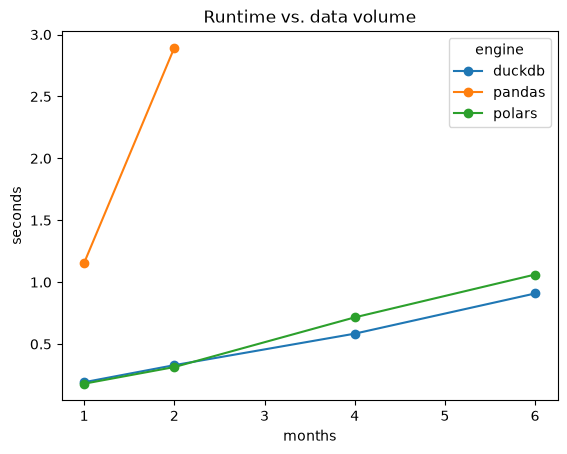

engine,duckdb,pandas,polars
months,,,
1,0.191577,1.156128,0.179598
2,0.329496,2.893920,0.314072
4,0.583716,NaN,0.715323
6,0.908474,NaN,1.061405


In [20]:
# How much RAM would pandas need? Measure one month, then extrapolate.
one_month_gb = pd.read_parquet(FILES[0]).memory_usage(deep=True).sum() / 1e9
avail_gb = psutil.virtual_memory().available / 1e9
print(f"pandas: ~{one_month_gb:.1f} GB per month in RAM (about 2x during concat) | available: {avail_gb:.1f} GB")

results = []
for n in sorted({n for n in [1, 2, 4, 8, 12] if n <= len(FILES)} | {len(FILES)}):
    subset = FILES[:n]
    print(f"--- {n} month(s)")
    for name, fn in [("pandas", lambda: run_pandas(subset)),
                     ("polars", lambda: polars_query(subset).collect()),
                     ("duckdb", lambda: con.execute(SQL, [subset]).pl())]:
        need_gb = n * one_month_gb * 2
        if name == "pandas" and need_gb > 0.8 * avail_gb:
            print(f"{name:<28} skipped – would need ~{need_gb:.0f} GB RAM, only {avail_gb:.0f} GB available")
            results.append({"months": n, "engine": name, "seconds": float("nan")}); continue
        _, dt = timed(name, fn)
        results.append({"months": n, "engine": name, "seconds": dt})

res = pd.DataFrame(results).pivot(index="months", columns="engine", values="seconds")
res.plot(marker="o", title="Runtime vs. data volume", ylabel="seconds"); plt.show()
res

## 8. Discussion (group work, 15 min)
1. Why are Polars and DuckDB faster *even on the same single machine*? (Think: GIL, cores, columnar layout, lazy plans.)
2. Estimate: how many months of taxi data could this machine handle with DuckDB? What limits it – RAM, disk, or CPU?
3. Name **two situations** where a single machine is *not* enough, even with DuckDB. → That is where Spark (next session) comes in.
4. Big Data is not only *Volume*. Which of the other Vs did today's lab ignore completely?

> 💡 Questions like these – *explain why engine X beats engine Y* – are typical exam questions.